In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("/content/IMDB Dataset.csv.zip")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2, random_state=42
)

In [ ]:
tokenizer = Tokenizer(num_words=15000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout

model = Sequential()

model.add(Embedding(input_dim=15000, output_dim=128, input_length=200))
model.add(GRU(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 235ms/step - accuracy: 0.8037 - loss: 0.4149 - val_accuracy: 0.8574 - val_loss: 0.3400
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9142 - loss: 0.2254 - val_accuracy: 0.9005 - val_loss: 0.2439
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 235ms/step - accuracy: 0.9495 - loss: 0.1453 - val_accuracy: 0.8973 - val_loss: 0.2789
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 232ms/step - accuracy: 0.9702 - loss: 0.0902 - val_accuracy: 0.8908 - val_loss: 0.3580
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.9827 - loss: 0.0544 - val_accuracy: 0.8872 - val_loss: 0.3758
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 238ms/step - accuracy: 0.9899 - loss: 0.0334 - val_accuracy: 0.8828 - val_loss: 0.4568
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 236ms/step - accuracy: 0.9930 - loss: 0.0241 - val_accuracy: 0.8830 - val_loss: 0.4900
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9942 -

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8783 - loss: 0.8018
Test Accuracy: 0.8783000111579895


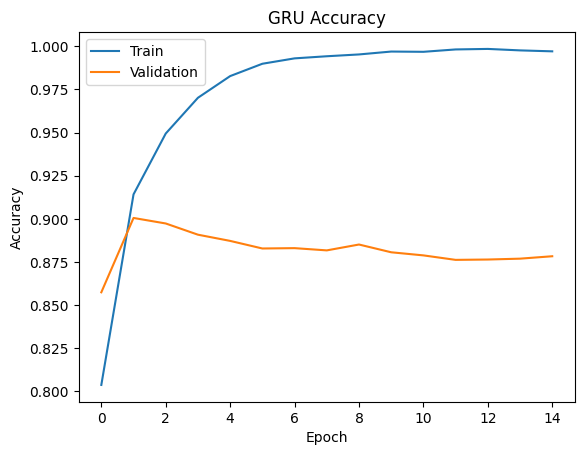

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
sample = ["This movie was great"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print("Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive 😊")
else:
    print("Negative 😠")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Score: 0.7716428
Positive 😊
